In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from ipywidgets import interact


plt.rcParams["figure.figsize"] = (6.0, 6.0)
plt.rcParams["figure.dpi"] = 200
plt.rcParams["font.size"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linewidth"] = 0.5
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.color"] = "0.5"

np.set_printoptions(precision=4, suppress=True)

In [2]:
def make_figure(xlim, ylim, figsize=(6.0, 6.0), dpi=200):
    """Создание фигуры и осей координат с единым масштабом."""
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(1, 1, 1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.grid(True)
    return fig, ax


def close_polygon(points):
    """Замыкание ломаной первым узлом."""
    return np.vstack((points, points[0]))


def unit_vector(angle_deg):
    """Единичный вектор под углом angle_deg к оси Ox."""
    angle_rad = np.deg2rad(angle_deg)
    return np.array([np.cos(angle_rad), np.sin(angle_rad)], dtype=np.float64)


def rotation_matrix(angle_deg):
    """Матрица поворота на угол angle_deg против часовой стрелки."""
    angle_rad = np.deg2rad(angle_deg)
    return np.array(
        [
            [np.cos(angle_rad), -np.sin(angle_rad)],
            [np.sin(angle_rad), np.cos(angle_rad)],
        ],
        dtype=np.float64,
    )


def reflection_matrix_from_line_angle(line_angle_deg):
    """Матрица отражения относительно прямой, образующей угол alpha с Ox."""
    theta_rad = np.deg2rad(2.0 * line_angle_deg)
    return np.array(
        [
            [np.cos(theta_rad), np.sin(theta_rad)],
            [np.sin(theta_rad), -np.cos(theta_rad)],
        ],
        dtype=np.float64,
    )


def rotate_points(points, angle_deg, center=None):
    """Поворот набора точек вокруг center."""
    if center is None:
        center = np.zeros(2, dtype=np.float64)
    matrix = rotation_matrix(angle_deg)
    return (matrix @ (points - center).T).T + center


def translate_points(points, vector):
    """Трансляция набора точек."""
    return points + vector


def reflect_points(points, line_angle_deg, point_on_line):
    """Отражение точек относительно прямой, проходящей через point_on_line."""
    matrix = reflection_matrix_from_line_angle(line_angle_deg)
    return (matrix @ (points - point_on_line).T).T + point_on_line


def centroid_vertices(points):
    """Центр масс как среднее арифметическое координат вершин."""
    return np.mean(points, axis=0)


def translation_vector(angle_deg, length):
    """Вектор трансляции, заданный в полярной форме."""
    return length * unit_vector(angle_deg)


def draw_airplane(ax, points, color="black", facecolor="none", linewidth=1.5,
                  linestyle="-", annotate=False, label_prefix=None, zorder=2):
    """Рисование многоугольника-самолета."""
    patch = mpatches.Polygon(
        points,
        closed=True,
        fill=(facecolor != "none"),
        edgecolor=color,
        facecolor=facecolor,
        linewidth=linewidth,
        linestyle=linestyle,
        alpha=0.15 if facecolor != "none" else 1.0,
        zorder=zorder,
    )
    ax.add_patch(patch)
    ax.plot(points[:, 0], points[:, 1], linestyle="None", marker="o",
            color=color, markersize=3, zorder=zorder + 1)
    if annotate:
        for index, point in enumerate(points):
            label = str(index) if label_prefix is None else f"{label_prefix}{index}"
            ax.text(point[0] + 0.15, point[1] + 0.15, label, color=color, zorder=zorder + 2)


def draw_center(ax, center, label, color="tab:red", dx=0.15, dy=0.15):
    """Рисование выделенной точки."""
    ax.plot(center[0], center[1], marker="o", color=color, markersize=5)
    ax.text(center[0] + dx, center[1] + dy, label, color=color)


def draw_line(ax, point_on_line, line_angle_deg, label=None, color="tab:blue"):
    """Бесконечная прямая через точку point_on_line."""
    direction = unit_vector(line_angle_deg)
    ax.axline(point_on_line, point_on_line + direction, color=color, linewidth=1.2)
    if label is not None:
        label_position = point_on_line + 1.2 * direction + np.array([0.2, 0.2])
        ax.text(label_position[0], label_position[1], label, color=color)


def to_complex(points):
    """Переход от двумерного массива координат к массиву комплексных чисел."""
    return points[:, 0] + 1j * points[:, 1]


def from_complex(values):
    """Переход от комплексных чисел к двумерным координатам."""
    return np.column_stack((np.real(values), np.imag(values)))


def complex_rotate(values, angle_deg, center=0.0 + 0.0j):
    """Поворот комплексных точек вокруг center."""
    u = np.exp(1j * np.deg2rad(angle_deg))
    return u * (values - center) + center


def complex_translate(values, translation):
    """Комплексная трансляция."""
    return values + translation


def complex_reflect(values, line_angle_deg, point_on_line=0.0 + 0.0j):
    """Отражение относительно прямой с углом alpha, проходящей через point_on_line."""
    u = np.exp(2j * np.deg2rad(line_angle_deg))
    return u * np.conjugate(values - point_on_line) + point_on_line

## Задание 1

Сначала зададим вершины невыпуклого многоугольника «самолет» из таблицы 1 и изобразим его на координатной плоскости.

Для поворота вокруг начала координат используется матрица

$$
R(\theta) =
\begin{pmatrix}
\cos \theta & -\sin \theta \\
\sin \theta & \cos \theta
\end{pmatrix}.
$$

Поворот вокруг произвольной точки $\mathbf{c}$ реализуется по формуле

$$
\mathbf{p}' = R(\theta)(\mathbf{p} - \mathbf{c}) + \mathbf{c}.
$$

Трансляция на вектор $\mathbf{t}$ задается формулой

$$
\mathbf{p}' = \mathbf{p} + \mathbf{t},
\qquad
\mathbf{t} =
\begin{pmatrix}
\rho \cos \varphi \\
\rho \sin \varphi
\end{pmatrix}.
$$

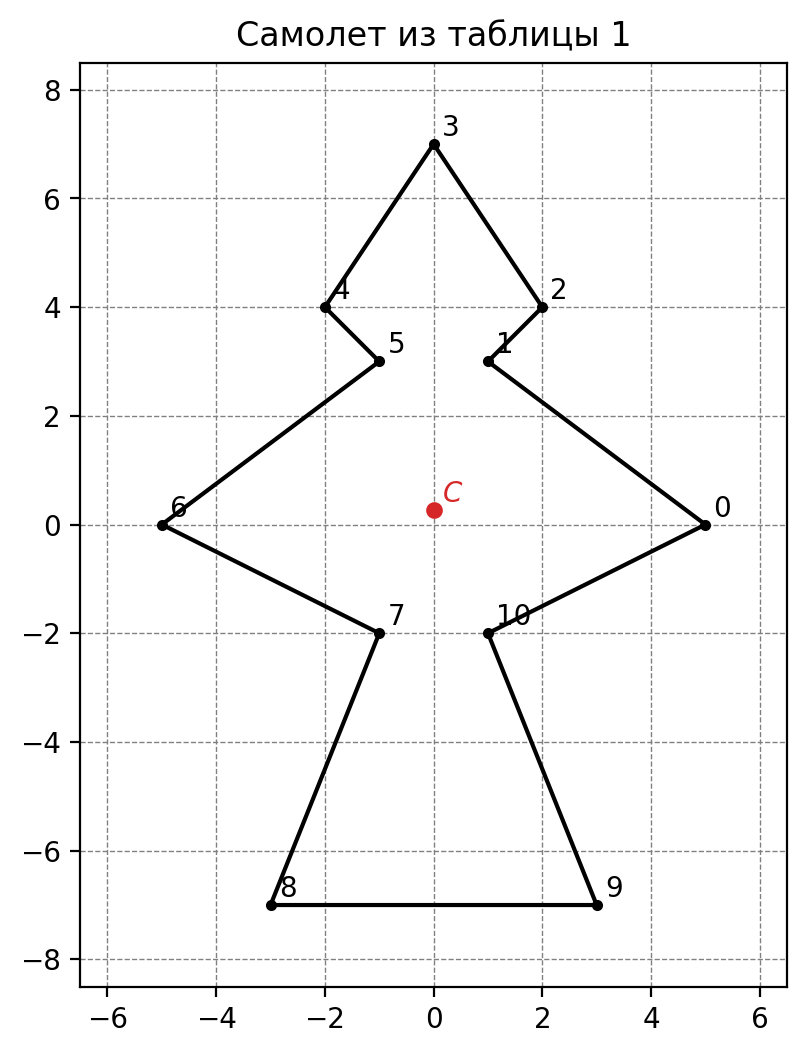

Координаты центра масс как среднего по вершинам:
[0.     0.2727]


In [3]:
airplane = np.array(
    [
        [5.0, 0.0],
        [1.0, 3.0],
        [2.0, 4.0],
        [0.0, 7.0],
        [-2.0, 4.0],
        [-1.0, 3.0],
        [-5.0, 0.0],
        [-1.0, -2.0],
        [-3.0, -7.0],
        [3.0, -7.0],
        [1.0, -2.0],
    ],
    dtype=np.float64,
)

control_task1 = np.array(
    [
        [12.7362, 9.4665],
        [8.1381, 7.5024],
        [7.7721, 8.8684],
        [4.1740, 8.6364],
        [5.7721, 5.4043],
        [7.1381, 5.7703],
        [7.7362, 0.8062],
        [11.4682, 3.2703],
        [14.7984, -0.9617],
        [17.7984, 4.2344],
        [12.4682, 5.0024],
    ],
    dtype=np.float64,
)

airplane_center = centroid_vertices(airplane)

fig, ax = make_figure(xlim=(-6.5, 6.5), ylim=(-8.5, 8.5))
draw_airplane(ax, airplane, color="black", annotate=True)
draw_center(ax, airplane_center, r"$C$", color="tab:red")
ax.set_title("Самолет из таблицы 1")
plt.show()

print("Координаты центра масс как среднего по вершинам:")
print(np.round(airplane_center, 4))

In [4]:
def plot_rotation_about_origin(angle_deg):
    """Поворот самолета вокруг начала координат."""
    rotated = rotate_points(airplane, angle_deg)

    fig, ax = make_figure(xlim=(-8.5, 8.5), ylim=(-8.5, 8.5))
    draw_airplane(ax, airplane, color="0.65", annotate=True)
    draw_airplane(ax, rotated, color="tab:blue", annotate=False)
    draw_center(ax, np.zeros(2), r"$O$", color="tab:red", dx=0.15, dy=-0.45)
    ax.set_title(f"Поворот вокруг начала координат, угол = {angle_deg:.0f}°")
    plt.show()


interact(plot_rotation_about_origin, angle_deg=(-180, 180, 1))

interactive(children=(IntSlider(value=0, description='angle_deg', max=180, min=-180), Output()), _dom_classes=…

<function __main__.plot_rotation_about_origin(angle_deg)>

In [6]:
def plot_rotation_about_point(angle_deg, center_x, center_y):
    """Поворот самолета вокруг произвольной точки."""
    center = np.array([center_x, center_y], dtype=np.float64)
    rotated = rotate_points(airplane, angle_deg, center=center)

    fig, ax = make_figure(xlim=(-10.0, 10.0), ylim=(-10.0, 10.0))
    draw_airplane(ax, airplane, color="0.7", annotate=False)
    draw_airplane(ax, rotated, color="tab:green", annotate=False)
    draw_center(ax, center, r"$C$", color="tab:red")
    ax.set_title(
        f"Поворот вокруг точки C = ({center_x:.1f}, {center_y:.1f}), угол = {angle_deg:.0f}°"
    )
    plt.show()


interact(
    plot_rotation_about_point,
    angle_deg=(-180, 180, 1),
    center_x=(-8.0, 8.0, 0.5),
    center_y=(-8.0, 8.0, 0.5),
)

interactive(children=(IntSlider(value=0, description='angle_deg', max=180, min=-180), FloatSlider(value=0.0, d…

<function __main__.plot_rotation_about_point(angle_deg, center_x, center_y)>

In [8]:
def plot_translation_polar(angle_deg, length):
    """Трансляция на вектор, заданный полярным углом и длиной."""
    vector = translation_vector(angle_deg, length)
    translated = translate_points(airplane, vector)

    fig, ax = make_figure(xlim=(-12.0, 12.0), ylim=(-12.0, 12.0))
    draw_airplane(ax, airplane, color="0.7", annotate=False)
    draw_airplane(ax, translated, color="tab:purple", annotate=False)
    ax.arrow(
        0.0,
        0.0,
        vector[0],
        vector[1],
        width=0.08,
        head_width=0.35,
        head_length=0.5,
        color="tab:red",
        length_includes_head=True,
    )
    ax.text(vector[0] + 0.25, vector[1] + 0.25, r"$\mathbf{t}$", color="tab:red")
    ax.set_title(
        f"Трансляция на вектор длины {length:.1f} под углом {angle_deg:.0f}°"
    )
    plt.show()


interact(plot_translation_polar, angle_deg=(-180, 180, 1), length=(0.0, 12.0, 0.25))

interactive(children=(IntSlider(value=0, description='angle_deg', max=180, min=-180), FloatSlider(value=6.0, d…

<function __main__.plot_translation_polar(angle_deg, length)>

Для проверки пункта 5 нужно подобрать преобразование из постановки.

Таблица 2 совпадает с результатом композиции:

1. поворот на угол $60^\circ$ вокруг центра масс, вычисленного как среднее арифметическое координат вершин;
2. трансляция на вектор
   $$
   \mathbf{t} =
   \begin{pmatrix}
   10 \\
   5
   \end{pmatrix}.
   $$

Ниже выполняется прямая проверка по контрольной таблице 2.

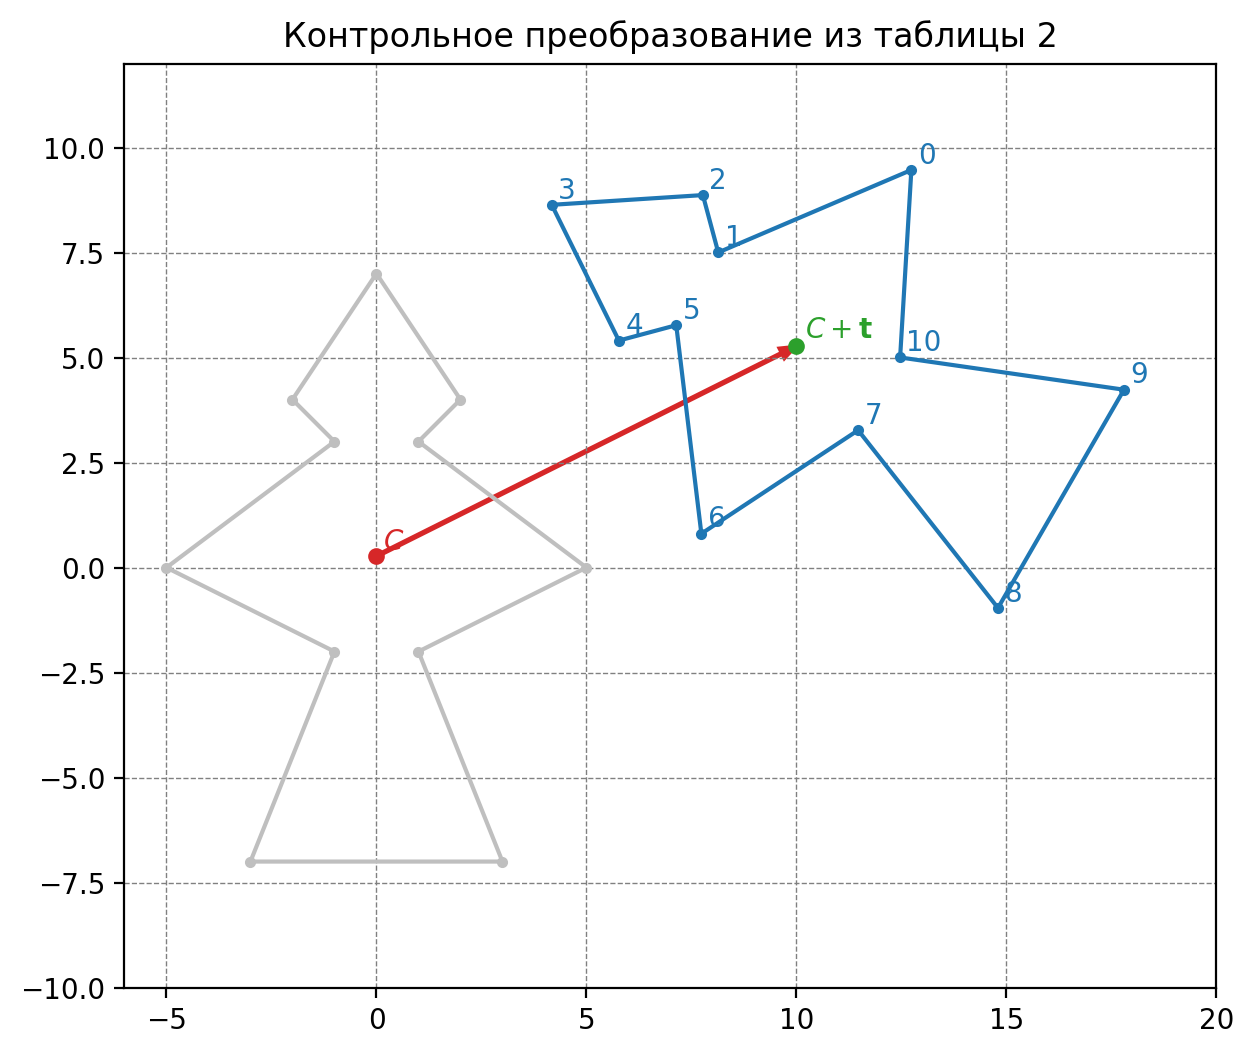

Максимальное отклонение от таблицы 2: 3.9847716951868506e-05
Первые пять вычисленных вершин:
[[12.7362  9.4665]
 [ 8.1381  7.5024]
 [ 7.7721  8.8684]
 [ 4.174   8.6364]
 [ 5.7721  5.4043]]


In [7]:
task1_translation = np.array([10.0, 5.0], dtype=np.float64)
task1_angle = 60.0

transformed_task1 = translate_points(
    rotate_points(airplane, task1_angle, center=airplane_center),
    task1_translation,
)

task1_error = np.max(np.abs(transformed_task1 - control_task1))

assert task1_error < 1e-3

fig, ax = make_figure(xlim=(-6.0, 20.0), ylim=(-10.0, 12.0), figsize=(7.5, 6.0))
draw_airplane(ax, airplane, color="0.75", annotate=False)
draw_airplane(ax, transformed_task1, color="tab:blue", annotate=True)
draw_center(ax, airplane_center, r"$C$", color="tab:red")
translated_center = airplane_center + task1_translation
draw_center(ax, translated_center, r"$C + \mathbf{t}$", color="tab:green", dx=0.2, dy=0.2)
ax.arrow(
    airplane_center[0],
    airplane_center[1],
    task1_translation[0],
    task1_translation[1],
    width=0.06,
    head_width=0.3,
    head_length=0.4,
    color="tab:red",
    length_includes_head=True,
)
ax.set_title("Контрольное преобразование из таблицы 2")
plt.show()

print("Максимальное отклонение от таблицы 2:", task1_error)
print("Первые пять вычисленных вершин:")
print(np.round(transformed_task1[:5], 4))

## Задание 2

Самолет из таблицы 3 получается из исходного самолета поворотом на $90^\circ$ против часовой стрелки вокруг начала координат:

$$
\begin{pmatrix}
x' \\
y'
\end{pmatrix}
=
R\left(90^\circ\right)
\begin{pmatrix}
x \\
y
\end{pmatrix}
=
\begin{pmatrix}
0 & -1 \\
1 & 0
\end{pmatrix}
\begin{pmatrix}
x \\
y
\end{pmatrix}
=
\begin{pmatrix}
-y \\
x
\end{pmatrix}.
$$

Для отражения относительно прямой, образующей угол $\alpha$ с осью $Ox$, используется матрица

$$
R_f(\theta) =
\begin{pmatrix}
\cos \theta & \sin \theta \\
\sin \theta & -\cos \theta
\end{pmatrix},
\qquad
\theta = 2\alpha.
$$

Геометрический смысл параметра $\theta$ таков: это удвоенный угол наклона отражающей прямой к оси $Ox$.

Если прямая не проходит через начало координат, то выбирается точка $\mathbf{c}$ на этой прямой, и отражение записывается в аффинном виде

$$
\mathbf{p}' = R_f(\theta)(\mathbf{p} - \mathbf{c}) + \mathbf{c}
= R_f(\theta)\mathbf{p} + \mathbf{t},
\qquad
\mathbf{t} = \mathbf{c} - R_f(\theta)\mathbf{c}.
$$

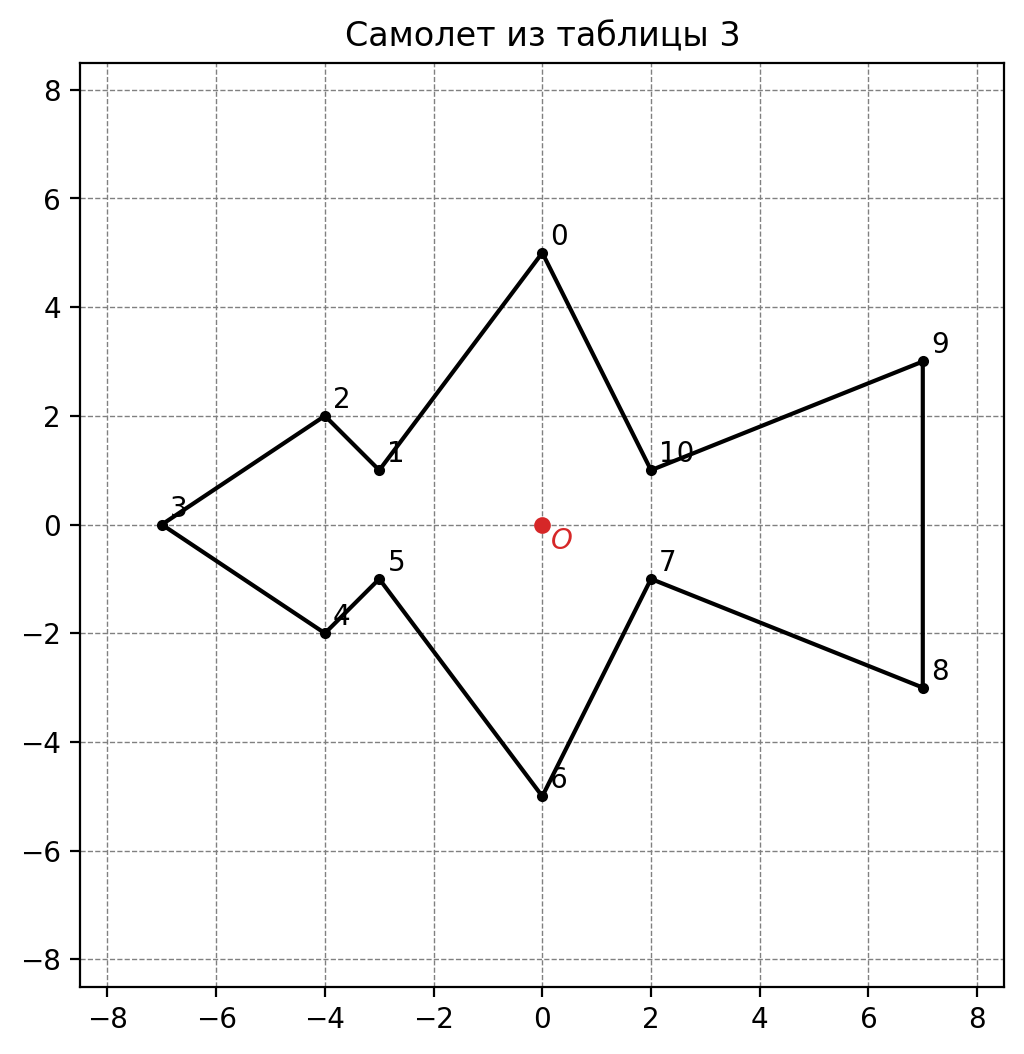

Максимальное отклонение таблицы 3 от поворота исходного самолета на 90°:
4.440892098500626e-16


In [10]:
airplane_side = rotate_points(airplane, 90.0)

control_first_reflection = np.array(
    [
        [3.1699, 10.4904],
        [5.1340, 15.0885],
        [3.7679, 15.4545],
        [4.0000, 19.0526],
        [7.2321, 17.4545],
        [6.8660, 16.0885],
        [11.8301, 15.4904],
        [9.3660, 11.7583],
        [13.5981, 8.4282],
        [8.4019, 5.4282],
        [7.6340, 10.7583],
    ],
    dtype=np.float64,
)

control_second_reflection = np.array(
    [
        [26.8301, 10.4904],
        [24.8660, 15.0885],
        [26.2321, 15.4545],
        [26.0000, 19.0526],
        [22.7679, 17.4545],
        [23.1340, 16.0885],
        [18.1699, 15.4904],
        [20.6340, 11.7583],
        [16.4019, 8.4282],
        [21.5981, 5.4282],
        [22.3660, 10.7583],
    ],
    dtype=np.float64,
)

control_table3 = np.array(
    [
        [0.0, 5.0],
        [-3.0, 1.0],
        [-4.0, 2.0],
        [-7.0, 0.0],
        [-4.0, -2.0],
        [-3.0, -1.0],
        [0.0, -5.0],
        [2.0, -1.0],
        [7.0, -3.0],
        [7.0, 3.0],
        [2.0, 1.0],
    ],
    dtype=np.float64,
)

assert np.allclose(airplane_side, control_table3)

fig, ax = make_figure(xlim=(-8.5, 8.5), ylim=(-8.5, 8.5))
draw_airplane(ax, airplane_side, color="black", annotate=True)
draw_center(ax, np.zeros(2), r"$O$", color="tab:red", dx=0.15, dy=-0.45)
ax.set_title("Самолет из таблицы 3")
plt.show()

print("Максимальное отклонение таблицы 3 от поворота исходного самолета на 90°:")
print(np.max(np.abs(airplane_side - control_table3)))

In [11]:
def plot_single_reflection(line_angle_deg, x_intercept):
    """Отражение лежащего самолета относительно одной прямой."""
    point_on_line = np.array([x_intercept, 0.0], dtype=np.float64)
    reflected = reflect_points(airplane_side, line_angle_deg, point_on_line)

    fig, ax = make_figure(xlim=(-12.0, 20.0), ylim=(-10.0, 20.0), figsize=(7.5, 6.0))
    draw_airplane(ax, airplane_side, color="0.7", annotate=False)
    draw_airplane(ax, reflected, color="tab:blue", annotate=False)
    draw_line(ax, point_on_line, line_angle_deg, label=r"$l_1$", color="tab:red")
    draw_center(ax, point_on_line, r"$c_1$", color="tab:red")
    ax.set_title(
        f"Отражение относительно прямой l1: угол = {line_angle_deg:.0f}°, x-пересечение = {x_intercept:.1f}"
    )
    plt.show()


interact(plot_single_reflection, line_angle_deg=(-90, 90, 1), x_intercept=(-10.0, 20.0, 0.5))

interactive(children=(IntSlider(value=0, description='line_angle_deg', max=90, min=-90), FloatSlider(value=5.0…

<function __main__.plot_single_reflection(line_angle_deg, x_intercept)>

In [13]:
def plot_double_reflection(angle_l1, x_l1, angle_l2, x_l2):
    """Последовательное отражение относительно двух прямых."""
    point_l1 = np.array([x_l1, 0.0], dtype=np.float64)
    point_l2 = np.array([x_l2, 0.0], dtype=np.float64)

    reflected_once = reflect_points(airplane_side, angle_l1, point_l1)
    reflected_twice = reflect_points(reflected_once, angle_l2, point_l2)

    fig, ax = make_figure(xlim=(-12.0, 32.0), ylim=(-10.0, 22.0), figsize=(8.0, 6.0))
    draw_airplane(ax, airplane_side, color="0.7", annotate=False)
    draw_airplane(ax, reflected_once, color="tab:blue", annotate=False)
    draw_airplane(ax, reflected_twice, color="tab:green", annotate=False)
    draw_line(ax, point_l1, angle_l1, label=r"$l_1$", color="tab:red")
    draw_line(ax, point_l2, angle_l2, label=r"$l_2$", color="tab:purple")
    ax.set_title("Два последовательных отражения")
    plt.show()


interact(
    plot_double_reflection,
    angle_l1=(-90, 90, 1),
    x_l1=(-10.0, 20.0, 0.5),
    angle_l2=(-90, 90, 1),
    x_l2=(-10.0, 20.0, 0.5),
)

interactive(children=(IntSlider(value=0, description='angle_l1', max=90, min=-90), FloatSlider(value=5.0, desc…

<function __main__.plot_double_reflection(angle_l1, x_l1, angle_l2, x_l2)>

Для контрольного рисунка 8 параметры прямых оказываются следующими:

- первая прямая:
  $$
  l_1: x + \sqrt{3} y = 15,
  $$
  то есть она проходит через точку $(15, 0)$ и образует угол $-30^\circ$ с осью $Ox$;
- вторая прямая:
  $$
  l_2: x = 15,
  $$
  то есть это вертикальная прямая через ту же точку пересечения.

Именно эти значения воспроизводят таблицы 5 и 6 с точностью до округления.

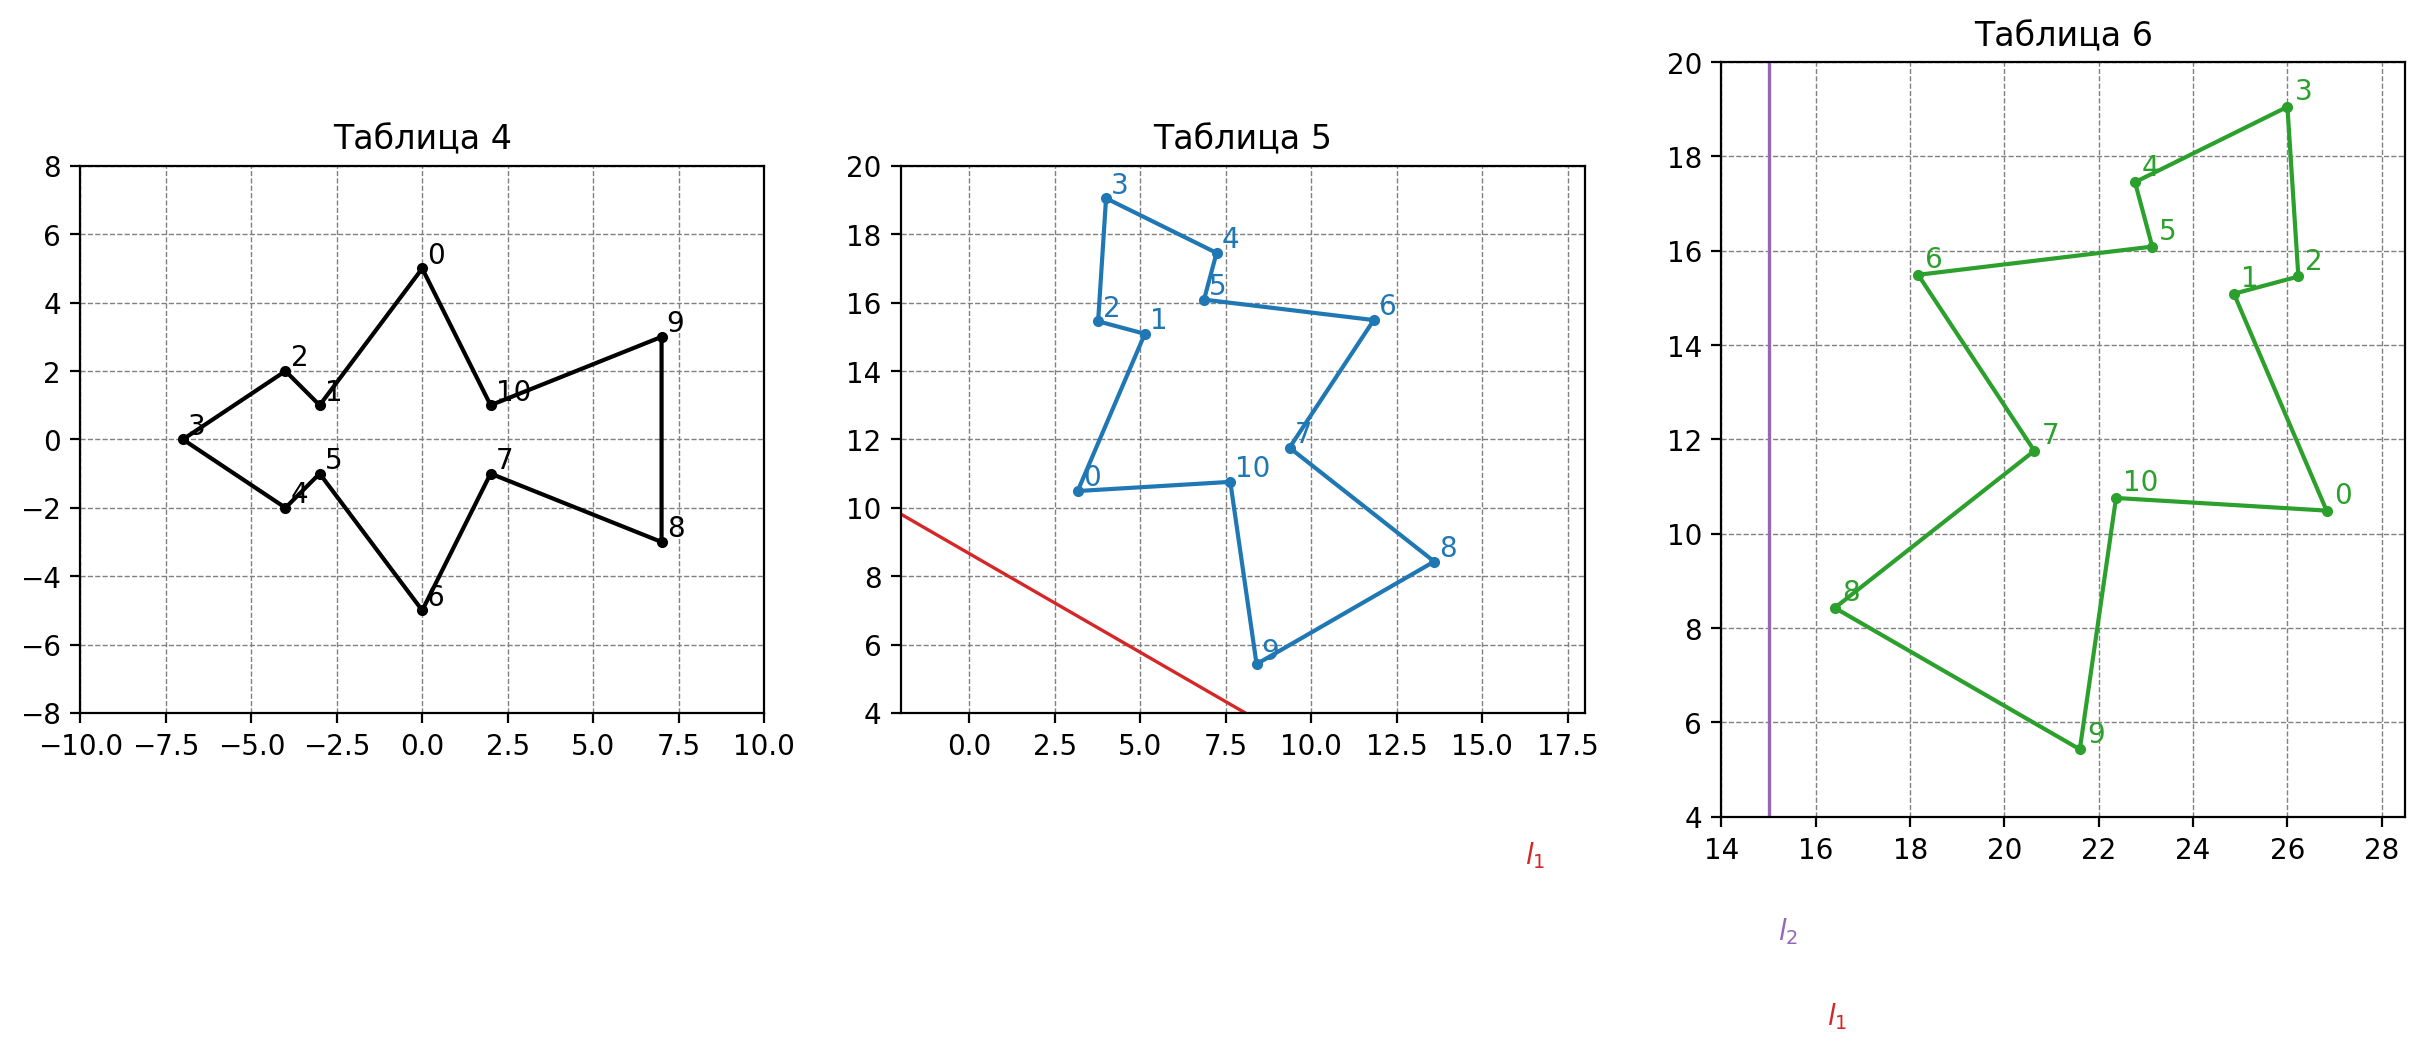

Максимальное отклонение от таблицы 5: 4.919243112500027e-05
Максимальное отклонение от таблицы 6: 4.919243112411209e-05
Максимальное отклонение второго отражения от поворота на -120°: 4.919243112411209e-05
Произведение матриц двух отражений:
[[-0.5    0.866]
 [-0.866 -0.5  ]]


In [19]:
l1_angle = -30.0
l1_point = np.array([15.0, 0.0], dtype=np.float64)
l2_angle = 90.0
l2_point = np.array([15.0, 0.0], dtype=np.float64)

reflected_once = reflect_points(airplane_side, l1_angle, l1_point)
reflected_twice = reflect_points(reflected_once, l2_angle, l2_point)

task2_error_once = np.max(np.abs(reflected_once - control_first_reflection))
task2_error_twice = np.max(np.abs(reflected_twice - control_second_reflection))

assert task2_error_once < 1e-3
assert task2_error_twice < 1e-3

intersection_point = np.array([15.0, 0.0], dtype=np.float64)
direct_rotation = rotate_points(airplane_side, -120.0, center=intersection_point)
task2_rotation_error = np.max(np.abs(direct_rotation - control_second_reflection))

assert task2_rotation_error < 1e-3

reflection_product = (
    reflection_matrix_from_line_angle(l2_angle)
    @ reflection_matrix_from_line_angle(l1_angle)
)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 5.0), dpi=200)

axes[0].set_xlim(-10.0, 10.0)
axes[0].set_ylim(-8.0, 8.0)
axes[0].set_aspect("equal")
axes[0].grid(True)
draw_airplane(axes[0], airplane_side, color="black", annotate=True)
axes[0].set_title("Таблица 4")

axes[1].set_xlim(-2.0, 18.0)
axes[1].set_ylim(4.0, 20.0)
axes[1].set_aspect("equal")
axes[1].grid(True)
draw_airplane(axes[1], reflected_once, color="tab:blue", annotate=True)
draw_line(axes[1], l1_point, l1_angle, label=r"$l_1$", color="tab:red")
axes[1].set_title("Таблица 5")

axes[2].set_xlim(14.0, 28.5)
axes[2].set_ylim(4.0, 20.0)
axes[2].set_aspect("equal")
axes[2].grid(True)
draw_airplane(axes[2], reflected_twice, color="tab:green", annotate=True)
draw_line(axes[2], l1_point, l1_angle, label=r"$l_1$", color="tab:red")
draw_line(axes[2], l2_point, l2_angle, label=r"$l_2$", color="tab:purple")
axes[2].set_title("Таблица 6")

plt.show()

print("Максимальное отклонение от таблицы 5:", task2_error_once)
print("Максимальное отклонение от таблицы 6:", task2_error_twice)
print("Максимальное отклонение второго отражения от поворота на -120°:", task2_rotation_error)
print("Произведение матриц двух отражений:")
print(np.round(reflection_product, 4))

Геометрические выводы по заданию 2:

- первое преобразование является именно отражением, потому что отражающая прямая служит серединным перпендикуляром к отрезкам, соединяющим каждую точку и ее образ;
- первое отражение нельзя получить поворотом исходной фигуры, так как отражение меняет ориентацию фигуры, а поворот ориентацию сохраняет;
- алгебраически это видно по определителю: у поворота $\det R = +1$, у отражения $\det R_f = -1$;
- второе отражение можно получить поворотом исходной фигуры, потому что композиция двух отражений относительно пересекающихся прямых есть поворот;
- в нашем случае прямая $l_1$ имеет угол $-30^\circ$, прямая $l_2$ имеет угол $90^\circ$, поэтому итоговый угол поворота равен
  $$
  2(90^\circ - (-30^\circ)) = 240^\circ,
  $$
  что эквивалентно повороту на $-120^\circ$ вокруг точки пересечения прямых $(15, 0)$.

## Задание 3

Теперь повторим основные преобразования с помощью комплексных чисел.

Точке $(x, y)$ ставится в соответствие число

$$
z = x + iy.
$$

Тогда:

- поворот на угол $\varphi$ вокруг начала координат задается умножением
  $$
  z' = e^{i\varphi} z;
  $$
- поворот вокруг точки $c$ задается формулой
  $$
  z' = e^{i\varphi}(z - c) + c;
  $$
- трансляция задается простым сложением
  $$
  z' = z + t;
  $$
- отражение относительно прямой с углом $\alpha$, проходящей через точку $c$, задается формулой
  $$
  z' = e^{2 i \alpha} \overline{(z - c)} + c.
  $$

Ниже приведены интерактивные иллюстрации и затем выполнена численная сверка с матричной реализацией.

Для работы с комплексными числами вершины самолета хранятся в виде массива

$$
z_k = x_k + i y_k.
$$

Библиотека `Matplotlib` не отображает такие точки напрямую, поэтому перед рисованием из массива комплексных чисел извлекаются действительная и мнимая части. В ноутбуке это делает функция `from_complex`, которая использует `np.real(...)` и `np.imag(...)` в точном соответствии с указанием из постановки.

Поворот вокруг начала координат является частным случаем формулы поворота вокруг произвольной точки: достаточно взять центр $c = 0$.

In [20]:
airplane_complex = to_complex(airplane)
airplane_side_complex = to_complex(airplane_side)


def plot_complex_rotation(angle_deg, center_x, center_y):
    center = center_x + 1j * center_y
    rotated = from_complex(complex_rotate(airplane_complex, angle_deg, center=center))

    fig, ax = make_figure(xlim=(-10.0, 10.0), ylim=(-10.0, 10.0))
    draw_airplane(ax, airplane, color="0.7", annotate=False)
    draw_airplane(ax, rotated, color="tab:blue", annotate=False)
    draw_center(ax, np.array([center_x, center_y]), r"$c$", color="tab:red")
    ax.set_title(
        f"Комплексный поворот: угол = {angle_deg:.0f}°, центр = ({center_x:.1f}, {center_y:.1f})"
    )
    plt.show()


interact(
    plot_complex_rotation,
    angle_deg=(-180, 180, 1),
    center_x=(-8.0, 8.0, 0.5),
    center_y=(-8.0, 8.0, 0.5),
)

interactive(children=(IntSlider(value=0, description='angle_deg', max=180, min=-180), FloatSlider(value=0.0, d…

<function __main__.plot_complex_rotation(angle_deg, center_x, center_y)>

In [21]:
def plot_complex_translation(angle_deg, length):
    translation = length * np.exp(1j * np.deg2rad(angle_deg))
    translated = from_complex(complex_translate(airplane_complex, translation))
    vector = np.array([translation.real, translation.imag], dtype=np.float64)

    fig, ax = make_figure(xlim=(-12.0, 12.0), ylim=(-12.0, 12.0))
    draw_airplane(ax, airplane, color="0.7", annotate=False)
    draw_airplane(ax, translated, color="tab:green", annotate=False)
    ax.arrow(
        0.0,
        0.0,
        vector[0],
        vector[1],
        width=0.08,
        head_width=0.35,
        head_length=0.5,
        color="tab:red",
        length_includes_head=True,
    )
    ax.text(vector[0] + 0.25, vector[1] + 0.25, r"$t$", color="tab:red")
    ax.set_title("Комплексная трансляция")
    plt.show()


interact(plot_complex_translation, angle_deg=(-180, 180, 1), length=(0.0, 12.0, 0.25))

interactive(children=(IntSlider(value=0, description='angle_deg', max=180, min=-180), FloatSlider(value=6.0, d…

<function __main__.plot_complex_translation(angle_deg, length)>

In [22]:
def plot_complex_double_reflection(angle_l1, x_l1, angle_l2, x_l2):
    point_l1 = x_l1 + 0j
    point_l2 = x_l2 + 0j

    reflected_once = from_complex(
        complex_reflect(airplane_side_complex, angle_l1, point_on_line=point_l1)
    )
    reflected_twice = from_complex(
        complex_reflect(to_complex(reflected_once), angle_l2, point_on_line=point_l2)
    )

    fig, ax = make_figure(xlim=(-12.0, 32.0), ylim=(-10.0, 22.0), figsize=(8.0, 6.0))
    draw_airplane(ax, airplane_side, color="0.7", annotate=False)
    draw_airplane(ax, reflected_once, color="tab:blue", annotate=False)
    draw_airplane(ax, reflected_twice, color="tab:green", annotate=False)
    draw_line(ax, np.array([x_l1, 0.0]), angle_l1, label=r"$l_1$", color="tab:red")
    draw_line(ax, np.array([x_l2, 0.0]), angle_l2, label=r"$l_2$", color="tab:purple")
    ax.set_title("Два отражения, выполненные комплексными числами")
    plt.show()


interact(
    plot_complex_double_reflection,
    angle_l1=(-90, 90, 1),
    x_l1=(-10.0, 20.0, 0.5),
    angle_l2=(-90, 90, 1),
    x_l2=(-10.0, 20.0, 0.5),
)

interactive(children=(IntSlider(value=0, description='angle_l1', max=90, min=-90), FloatSlider(value=5.0, desc…

<function __main__.plot_complex_double_reflection(angle_l1, x_l1, angle_l2, x_l2)>

In [23]:
def plot_complex_single_reflection(angle_l1, x_l1):
    point_l1 = x_l1 + 0j
    reflected = from_complex(
        complex_reflect(airplane_side_complex, angle_l1, point_on_line=point_l1)
    )

    fig, ax = make_figure(xlim=(-12.0, 20.0), ylim=(-10.0, 20.0), figsize=(7.5, 6.0))
    draw_airplane(ax, airplane_side, color="0.7", annotate=False)
    draw_airplane(ax, reflected, color="tab:blue", annotate=False)
    draw_line(ax, np.array([x_l1, 0.0]), angle_l1, label=r"$l_1$", color="tab:red")
    draw_center(ax, np.array([x_l1, 0.0]), r"$c_1$", color="tab:red")
    ax.set_title("Одно отражение, выполненное комплексными числами")
    plt.show()


interact(
    plot_complex_single_reflection,
    angle_l1=(-90, 90, 1),
    x_l1=(-10.0, 20.0, 0.5),
)

interactive(children=(IntSlider(value=0, description='angle_l1', max=90, min=-90), FloatSlider(value=5.0, desc…

<function __main__.plot_complex_single_reflection(angle_l1, x_l1)>

In [24]:
complex_task1 = from_complex(
    complex_translate(
        complex_rotate(
            airplane_complex,
            task1_angle,
            center=airplane_center[0] + 1j * airplane_center[1],
        ),
        task1_translation[0] + 1j * task1_translation[1],
    )
)

complex_task2_once = from_complex(
    complex_reflect(airplane_side_complex, l1_angle, point_on_line=l1_point[0] + 0j)
)
complex_task2_twice = from_complex(
    complex_reflect(
        to_complex(complex_task2_once),
        l2_angle,
        point_on_line=l2_point[0] + 0j,
    )
)

matrix_vs_complex_task1 = np.max(np.abs(transformed_task1 - complex_task1))
matrix_vs_complex_task2_once = np.max(np.abs(reflected_once - complex_task2_once))
matrix_vs_complex_task2_twice = np.max(np.abs(reflected_twice - complex_task2_twice))

assert matrix_vs_complex_task1 < 1e-10
assert matrix_vs_complex_task2_once < 1e-10
assert matrix_vs_complex_task2_twice < 1e-10

print("Сверка матричного и комплексного подходов:")
print("Задание 1, пункт 5:", matrix_vs_complex_task1)
print("Задание 2, первое отражение:", matrix_vs_complex_task2_once)
print("Задание 2, второе отражение:", matrix_vs_complex_task2_twice)

print()
print("Отклонение комплексных вычислений от контрольных таблиц:")
print("Таблица 2:", np.max(np.abs(complex_task1 - control_task1)))
print("Таблица 5:", np.max(np.abs(complex_task2_once - control_first_reflection)))
print("Таблица 6:", np.max(np.abs(complex_task2_twice - control_second_reflection)))

NameError: name 'task1_angle' is not defined

Преимущества комплексных чисел по сравнению с двумерными векторами в этой задаче:

- запись формул короче: поворот это одно умножение на $e^{i\varphi}$, отражение это одно сопряжение и одно умножение;
- меньше индексной работы, потому что не нужно явно хранить и перемножать матрицы $2 \times 2$;
- композиции преобразований на плоскости записываются компактно и читаются почти как геометрические формулы;
- особенно удобно выполнять аналитические преобразования в двумерном случае.

Ограничение у этого подхода тоже есть: он естественен именно для плоскости. Для трехмерных задач матричный подход остается более универсальным.